# 1 — Baselines (nothing learned)

Zero-deviation forward–backward splitting and the random-deviation control, on
one held-out Mayo slice. No trained model is needed.

Figures are saved as PDF in `plots/` (prefix `1_`).

In [1]:
import torch

from utils.experiments import (build_test_instance, reference_solution, run_fbs,
                               random_direction, objective_gap, time_table)
from utils.plots import apply_paper_style, plot_curves, show_images

apply_paper_style()

In [ ]:
# --- configuration (must match main.py) ---------------------------------------
SIZE = 512
N_ANGLES = 180
NOISE_LEVEL = 0.05
GAMMA = 2
PRIMAL_STEP = 1            # primal step tau (see main.py)

TEST_PATIENT = "L014"      # never used for training or validation
TEST_SLICE = 0
MAYO_CACHE_DIR = "./data/mayo_cache_512"

T_TRAIN = 10               # unrolling horizon used in training
T_LONG = 100               # length of the convergence curves
T_REF = 6000               # length of the run that defines F* (cached in results/)

In [3]:
inst = build_test_instance(SIZE, N_ANGLES, NOISE_LEVEL, GAMMA, TEST_PATIENT, TEST_SLICE,
                           MAYO_CACHE_DIR, primal_step=PRIMAL_STEP)
ref = reference_solution(inst, T_REF)
print(f"F* = {ref['f_star']:.4f}, PSNR of the TGV2 solution = {ref['psnr']:.2f} dB")

F* = 0.6605, PSNR of the TGV2 solution = 26.81 dB


## The problem

Ground truth, naive back-projection $K^\top y$, and the TGV$^2$ solution the algorithms converge to.

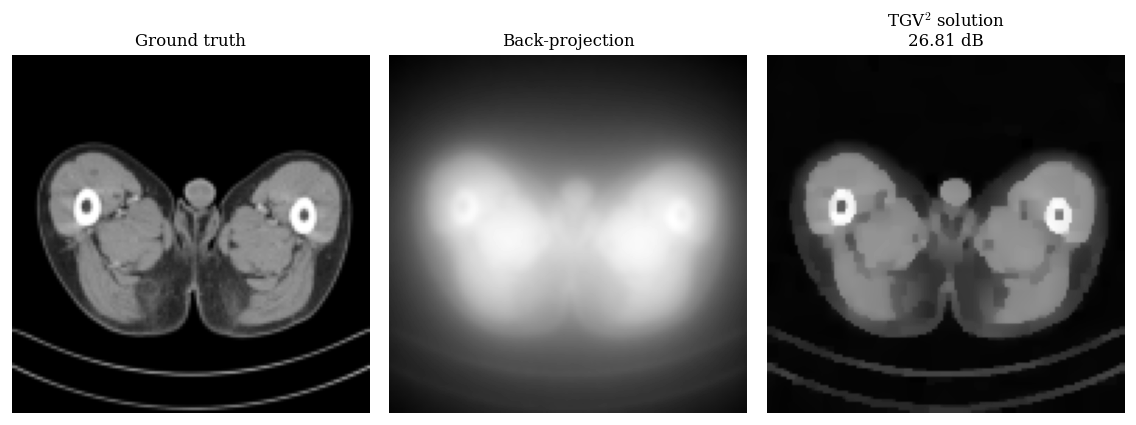

In [4]:
show_images({"Ground truth": inst["clean"],
             "Back-projection": inst["back_projection"],
             f"TGV$^2$ solution\n{ref['psnr']:.2f} dB": ref["image"]},
            "1_problem", clim=None, show=True)

## Runs

In [5]:
results = {
    "Zero deviation": run_fbs(inst, T_LONG, snapshots=(T_TRAIN,)),
    "Random": run_fbs(inst, T_LONG, random_direction(seed=0), snapshots=(T_TRAIN,)),
}

## Convergence

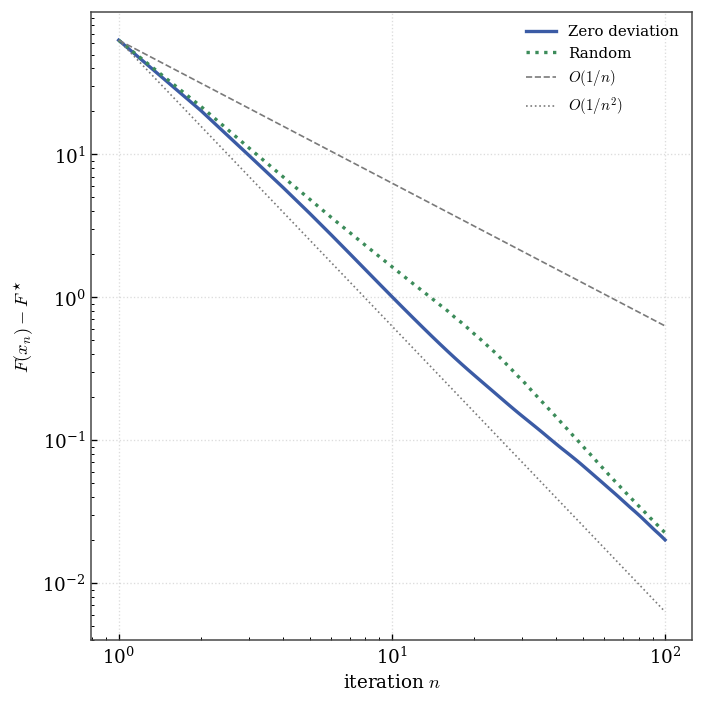

In [6]:
gaps = {label: objective_gap(r, ref["f_star"]) for label, r in results.items()}
plot_curves(gaps, r"$F(x_n) - F^\star$", "1_objective_gap", slopes=True, iteration_start=0, show=True)

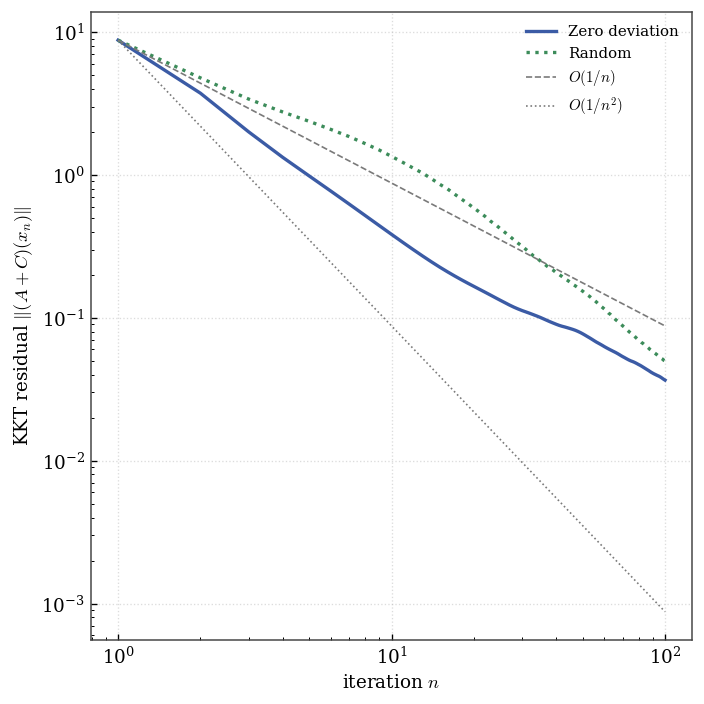

In [7]:
plot_curves({label: r["kkt"] for label, r in results.items() if "kkt" in r},
            r"KKT residual $\|(A + C)(x_n)\|$", "1_kkt", slopes=True, show=True)

## PSNR

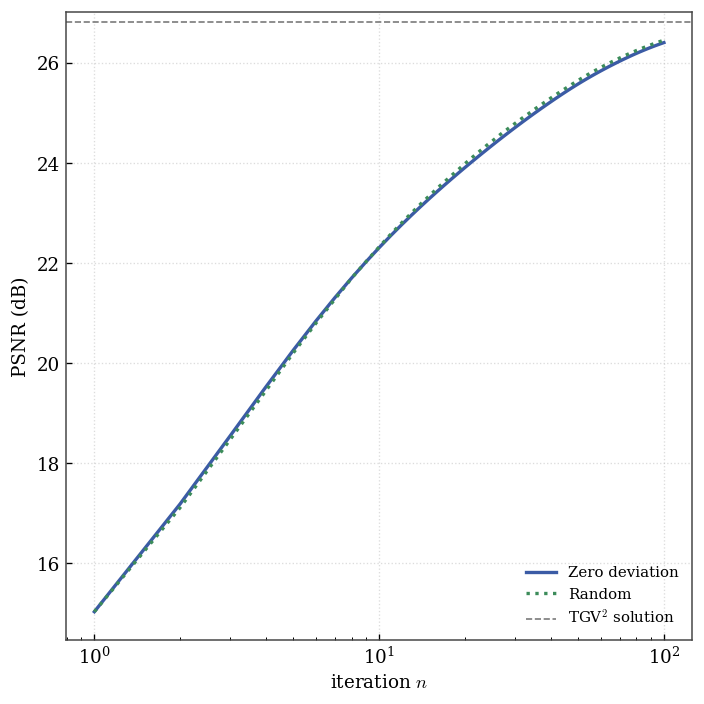

In [8]:
plot_curves({label: r["psnr"] for label, r in results.items()}, "PSNR (dB)", "1_psnr",
            loglog=False, hline=(ref["psnr"], r"TGV$^2$ solution"), iteration_start=0, show=True)

## Reconstructions

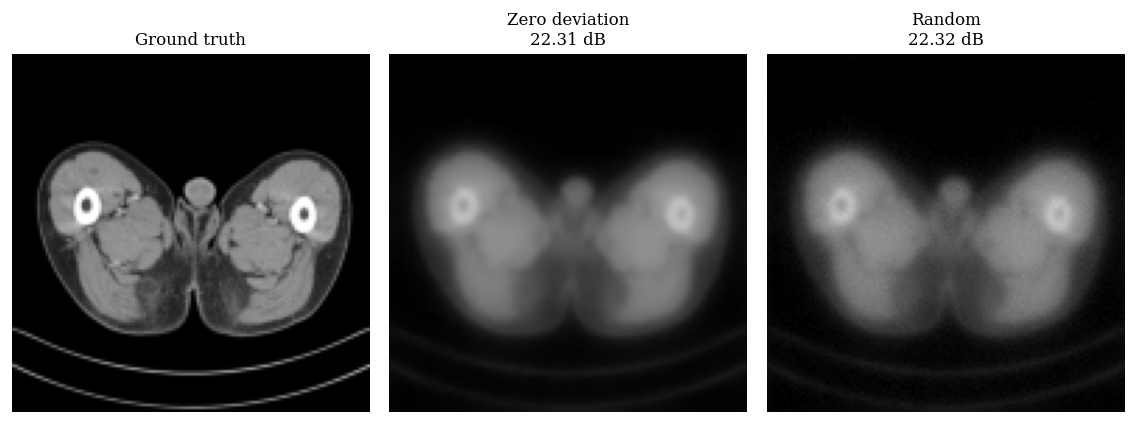

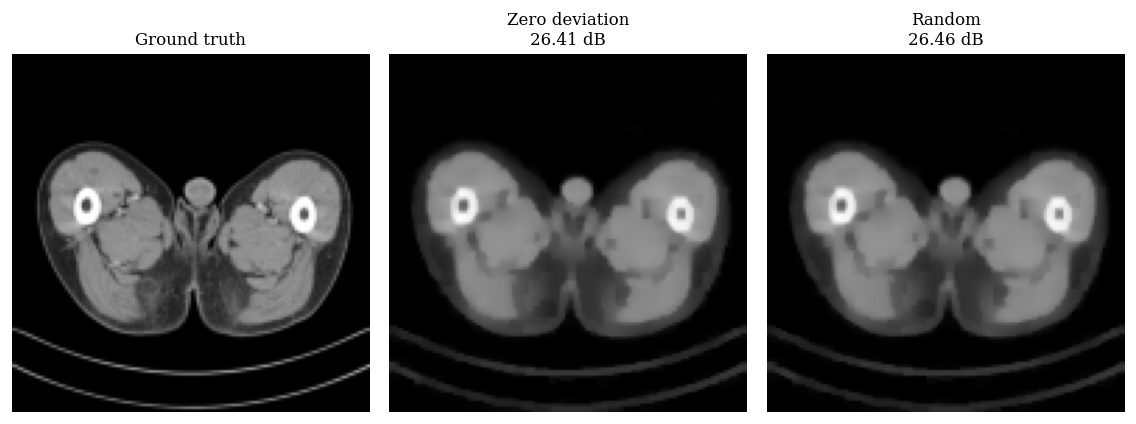

In [9]:
def gallery(n):
    """Ground truth and the reconstruction of every method after n iterations."""
    images = {"Ground truth": inst["clean"]}
    for label, r in results.items():
        images[f"{label}\n{r['psnr'][n]:.2f} dB"] = r["images"][n]
    return images

show_images(gallery(T_TRAIN), "1_reconstructions_{}_iterations".format(T_TRAIN), show=True)
show_images(gallery(T_LONG), "1_reconstructions_{}_iterations".format(T_LONG), show=True)

## Time comparison

Time per iteration is measured on a separate short run without any monitoring
(no KKT residual, objective or PSNR computed). The table is also written as
LaTeX in `plots/`.

In [ ]:
time_table(results, name="1_time_comparison")